Experimentos UNIOVI:

- Inicialmente vamos a realizar un estudio de los verbos que hay mas presentes en las noticas, para asi sacar mejor las relaciones a obtener. 

-  Tras esto vamos a realizar por un lado una funcion de desambiguacion por nombres basada en 3 elementos, que el nombre aparezca completo, que el nombre aparezca como una combinacion de partes del nombre completo, que el nombre matchee con un nombre difuso, y finalmente por desambiguacion por contexto, es decir, si una persona pertenece a un grupo de informatica y la notica es de informática, elegir a esta frente a otra con el mismo nombre que pertence a un grupo de ciencias politicas. 

-Tras esto, vamos a obtener las relaciones mas comunes en forma de tripletas y a construir un grafo de conocimiento que podrá ser usado para enriquecer un RAG. 

- Tambien, usaremos estas relaciones para entrenar un clasificador de relaciones. 




In [ ]:
import json
import spacy
from spacy.matcher import PhraseMatcher
import unicodedata
import pandas as pd
from rapidfuzz import process, fuzz
from collections import defaultdict
import os
from openai import OpenAI
from pydantic import BaseModel, Field
from enum import Enum

# API para openai
os.environ["OPENAI_API_KEY"] = ""
client = OpenAI()

# 1. Función de normalización 
def normalizar_texto(texto):
    if not texto or not isinstance(texto, str): return ""
    texto = texto.lower()
    texto = ''.join(c for c in unicodedata.normalize('NFD', texto) if unicodedata.category(c) != 'Mn')
    return texto.strip()

# Cargar spaCy vacio para tokenizar
nlp_fast = spacy.blank("es")
nlp_ner = spacy.load("es_core_news_sm")

In [6]:
grupos = pd.read_json("./datos/grupos_detalle.json")
centros = pd.read_json("./datos/centros_detalle.json")
noticias = pd.read_json("./datos/noticias_uniovi.json")

diccionario_investigadores = {}

# Cream os el diccionario con Grupos y su contexto
for _, grupo in grupos.iterrows():
    departamento = grupo.get("departamento", "No especificado")
    area = grupo.get("area_conocimiento", "No especificada")
    nombre_grupo = grupo.get("nombre_grupo", "")

    for miembro in grupo.get("miembros", []) + grupo.get("colaboradores", []):
        if isinstance(miembro, dict) and "url_detalle" in miembro:
            id_unico = miembro["url_detalle"]
            nombre_oficial = miembro["nombre"]

            if id_unico not in diccionario_investigadores:
                diccionario_investigadores[id_unico] = {
                    "nombre_oficial": nombre_oficial,
                    "departamento": departamento,
                    "area_conocimiento": area,
                    "grupos": [nombre_grupo] if nombre_grupo else [],
                    "centros": []
                }
            else:
                if nombre_grupo and nombre_grupo not in diccionario_investigadores[id_unico]["grupos"]:
                    diccionario_investigadores[id_unico]["grupos"].append(nombre_grupo)

# Enriquecemos con Centros
for _, centro in centros.iterrows():
    nombre_centro = centro.get("nombre_centro", "")
    if "investigadores" in centro and isinstance(centro["investigadores"], list):
        for inv in centro.get("investigadores", []):
            if isinstance(inv, dict) and "url_detalle" in inv:
                id_unico = inv["url_detalle"]
                if id_unico in diccionario_investigadores:
                    if nombre_centro and nombre_centro not in diccionario_investigadores[id_unico]["centros"]:
                        diccionario_investigadores[id_unico]["centros"].append(nombre_centro)
                else:
                    diccionario_investigadores[id_unico] = {
                        "nombre_oficial": inv["nombre"],
                        "departamento": "No especificado",
                        "area_conocimiento": "No especificada",
                        "grupos": [],
                        "centros": [nombre_centro]
                    }

print(f"Indexados {len(diccionario_investigadores)} investigadores con su contexto (centros de trabajo, departamentos etc para poder desambiguar en caso necesario).")

Indexados 2285 investigadores con su contexto (centros de trabajo, departamentos etc para poder desambiguar en caso necesario).


In [9]:
def generar_alias_validos(nombre_completo):
    """Genera alias obligando a que incluyan siempre un apellido,
    contemplando la omisión del primer nombre en nombres compuestos."""

    nombre_clean = normalizar_texto(nombre_completo).upper()

    # Limpiamos conectores comunes que rompen el conteo de palabras
    palabras_crudas = nombre_clean.split()
    palabras = [p for p in palabras_crudas if p not in ["DE", "LA", "LAS", "DEL", "LOS", "Y"]]

    alias = set([nombre_clean]) # El nombre completo original siempre entra

    # CASO: 4 palabras (Nombre1, Nombre2, Apellido1, Apellido2)
    # Ejemplo: SUSANA IRENE DIAZ RODRIGUEZ
    if len(palabras) == 4:
        n1, n2, a1, a2 = palabras
        alias.update([
            f"{n1} {n2} {a1}",       # SUSANA IRENE DIAZ
            f"{n1} {a1} {a2}",       # SUSANA DIAZ RODRIGUEZ
            f"{n2} {a1} {a2}",       # IRENE DIAZ RODRIGUEZ
            f"{n1} {a1}",            # SUSANA DIAZ
            f"{n2} {a1}",            # IRENE DIAZ
            f"{a1} {a2}"             # DIAZ RODRIGUEZ
        ])

    # CASO: 3 palabras (Nombre, Apellido1, Apellido2)
    # Ejemplo: IRENE DIAZ MARTINEZ
    elif len(palabras) == 3:
        n, a1, a2 = palabras
        alias.update([
            f"{n} {a1}",             # IRENE DIAZ
            f"{a1} {a2}"             # DIAZ MARTINEZ
        ])

    # CASO: 5 o más palabras (Nombres muy largos)
    elif len(palabras) >= 5:
        a1, a2 = palabras[-2], palabras[-1]
        n1, n2 = palabras[0], palabras[1]
        alias.update([
            f"{n1} {a1} {a2}",
            f"{n2} {a1} {a2}",
            f"{n1} {a1}",
            f"{n2} {a1}",
            f"{a1} {a2}"
        ])

    return list(alias)

mapa_alias_a_ids = defaultdict(list)
lista_alias_norm = []

for id_unico, datos in diccionario_investigadores.items():
    alias_validos = generar_alias_validos(datos["nombre_oficial"])
    for a in alias_validos:
        alias_norm = normalizar_texto(a)
        mapa_alias_a_ids[alias_norm].append(id_unico)
        lista_alias_norm.append(alias_norm)

lista_alias_norm = list(set(lista_alias_norm)) # Quitamos duplicados para RapidFuzz

# Poblamos el PhraseMatcher exacto
matcher = PhraseMatcher(nlp_fast.vocab, attr="LOWER")
for alias_norm in mapa_alias_a_ids.keys():
    matcher.add(alias_norm, [nlp_fast.make_doc(alias_norm)])

print(f"Generados {len(mapa_alias_a_ids)} alias seguros para búsqueda (incluyendo segundos nombres con apellidos).")

Generados 9015 alias seguros para búsqueda (incluyendo segundos nombres con apellidos).


Vamos a crear una funcion, que para un nombre crea tres candidatos en funcion de restrictivo, que salga el nombre completo o su alias, que salga el nombre parecido (difuso) en caso de seguir habiendo dos, lo sacamos por el contexto de la noticia y el departamento asociado


In [10]:

def detectar_candidatos(texto_completo):
    texto_norm = normalizar_texto(texto_completo)
    ids_encontradas = set()

    # 1. Match Exacto con PhraseMatcher
    doc_fast = nlp_fast(texto_norm)
    coincidencias = matcher(doc_fast)
    for match_id, start, end in coincidencias:
        alias_encontrado = nlp_fast.vocab.strings[match_id]
        for i in mapa_alias_a_ids[alias_encontrado]:
            ids_encontradas.add(i)

    # 2. Match Difuso con NER
    doc_ner = nlp_ner(texto_completo)
    for entidad in doc_ner.ents:
        if entidad.label_ == "PER":
            entidad_norm = normalizar_texto(entidad.text)
            if len(entidad_norm.split()) > 1: # Ignorar una sola palabra
                resultado = process.extractOne(
                    entidad_norm,
                    lista_alias_norm,
                    scorer=fuzz.token_sort_ratio
                )
                if resultado and resultado[1] > 85:
                    mejor_alias = resultado[0]
                    for i in mapa_alias_a_ids[mejor_alias]:
                        ids_encontradas.add(i)

    # 3. Construir lista de contexto para el LLM
    candidatos_contexto = []
    for id_url in ids_encontradas:
        info = diccionario_investigadores[id_url]
        candidatos_contexto.append({
            "id_url": id_url,
            "nombre": info["nombre_oficial"],
            "departamento": info["departamento"],
            "grupos": info["grupos"]
        })

    return candidatos_contexto

In [ ]:
class TipoRelacion(str, Enum):
    LIDERA = "LIDERA"
    INVESTIGA_SOBRE = "INVESTIGA_SOBRE"
    DESARROLLA = "DESARROLLA"
    COLABORA_EN = "COLABORA_EN"

class TripletaInvestigacion(BaseModel):
    investigador_id: str = Field(description="URL/ID exacta seleccionada de la lista de CANDIDATOS.")
    relacion: TipoRelacion = Field(description="Verbo de relación normalizado.")
    topico_o_concepto: str = Field(description="Área, tecnología o concepto específico.")
    evidencia: str = Field(description="Cita textual corta que respalda la extracción.")

class ExtraerNoticiaResponse(BaseModel):
    tripletas: list[TripletaInvestigacion]

def extraer_con_llm(titulo, resumen, cuerpo, candidatos):
    prompt_sistema = """
    Extrae tripletas semánticas de investigación del texto.

    REGLA DE DESAMBIGUACIÓN ESTRICTA:
    1. Usa ÚNICAMENTE las `id_url` proporcionadas en los CANDIDATOS.
    2. Si el texto menciona un nombre ambiguo (ej. "Irene Díaz") y hay varios candidatos con ese nombre, lee el contexto de la noticia y compáralo con el "departamento" o "grupos" de los candidatos para elegir la `id_url` correcta.
    3. Si no puedes deducir cuál es el correcto con seguridad, ignora esa relación.
    """

    prompt_usuario = f"""
    --- NOTICIA ---
    Título: {titulo}
    Texto: {resumen} {cuerpo}

    --- CANDIDATOS DETECTADOS ---
    {json.dumps(candidatos, ensure_ascii=False, indent=2)}
    """

    completion = client.beta.chat.completions.parse(
        model="gpt-4o-mini",
        messages=[
            {"role": "system", "content": prompt_sistema},
            {"role": "user", "content": prompt_usuario}
        ],
        response_format=ExtraerNoticiaResponse,
        temperature=0.0
    )
    return completion.choices[0].message.parsed.tripletas

In [12]:
todas_las_tripletas = []

noticias_a_procesar = noticias

for index, row in noticias_a_procesar.iterrows():
    texto_completo = f"{row['titulo']} {row['resumen']} {row['noticia']}"

    # FASE 1: Detectar
    candidatos = detectar_candidatos(texto_completo)

    if not candidatos:
        continue

    print(f"[{index}] Noticia: {row['titulo'][:50]}... ({len(candidatos)} candidatos detectados)")

    try:
        # FASE 2: Extraer y Desambiguar
        tripletas = extraer_con_llm(row['titulo'], row['resumen'], row['noticia'], candidatos)

        for t in tripletas:
            if t.investigador_id in diccionario_investigadores:
                nombre = diccionario_investigadores[t.investigador_id]['nombre_oficial']
                print(f"  └─ ⟨{nombre} -> {t.relacion.value} -> {t.topico_o_concepto}⟩")

                todas_las_tripletas.append({
                    "investigador_id": t.investigador_id,
                    "nombre_investigador": nombre,
                    "relacion": t.relacion.value,
                    "topico": t.topico_o_concepto,
                    "evidencia": t.evidencia,
                    "noticia_index": index
                })
    except Exception as e:
        print(f"Error: {e}")

# Guardar Resultados
df_resultados = pd.DataFrame(todas_las_tripletas)
df_resultados.to_csv("tripletas_finales_desambiguadas.csv", index=False)
print(f"\n✅ Proceso completado. Guardadas {len(df_resultados)} tripletas.")

[0] Noticia: La nueva Junta Rectora de CRUE se reúne con el pre... (1 candidatos detectados)
  └─ ⟨IGNACIO VILLAVERDE MENENDEZ -> COLABORA_EN -> financiación pública de las universidades⟩
  └─ ⟨IGNACIO VILLAVERDE MENENDEZ -> COLABORA_EN -> inteligencia artificial⟩
  └─ ⟨IGNACIO VILLAVERDE MENENDEZ -> COLABORA_EN -> transformación digital de las universidades⟩
[1] Noticia: La Universidad de Oviedo reconstruye los orígenes ... (2 candidatos detectados)
  └─ ⟨JAVIER DE ANDRES SUAREZ -> INVESTIGA_SOBRE -> contabilidad de la Real Compañía Asturiana de Minas⟩
  └─ ⟨PEDRO LORCA FERNANDEZ -> INVESTIGA_SOBRE -> contabilidad de la Real Compañía Asturiana de Minas⟩
  └─ ⟨JAVIER DE ANDRES SUAREZ -> INVESTIGA_SOBRE -> sistema de contabilidad por partida simple⟩
  └─ ⟨PEDRO LORCA FERNANDEZ -> INVESTIGA_SOBRE -> sistema de contabilidad por partida simple⟩
[2] Noticia: La Universidá Asturiana de Branu incorpora la inte... (2 candidatos detectados)
  └─ ⟨XOSE ANTON GONZALEZ RIAÑO -> COLABORA_EN -> inte

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_72456/234212005.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


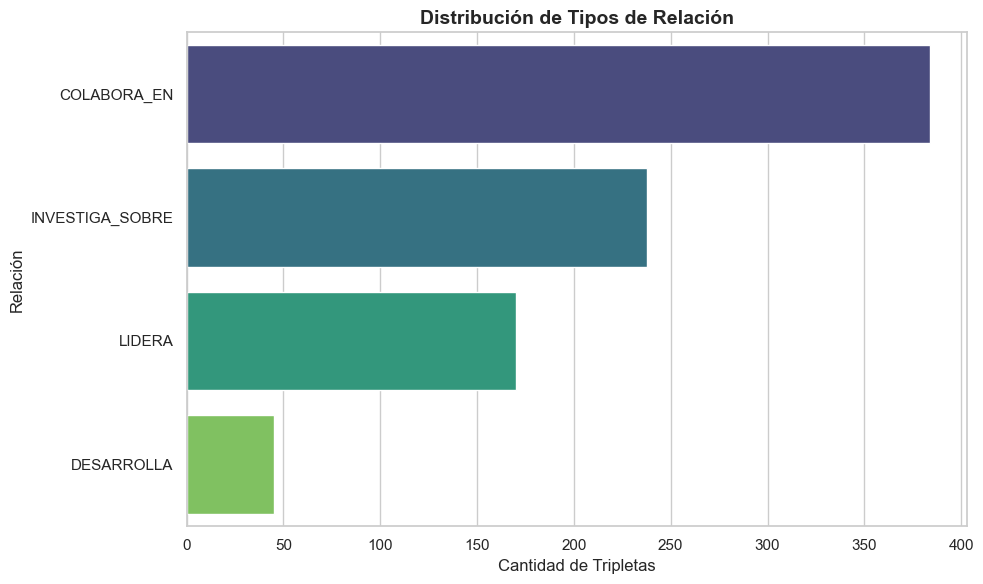

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_72456/234212005.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_investigadores.values, y=top_investigadores.index, palette="mako")


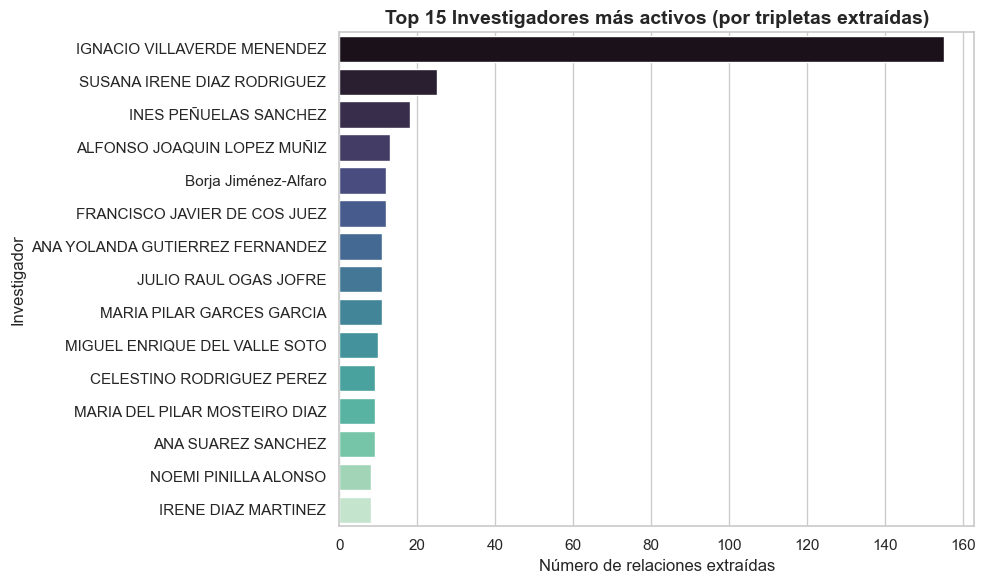

/var/folders/hx/tzq4mbtj1pj4gvxnfzdmx14h0000gq/T/ipykernel_72456/234212005.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=topicos_limpios.values, y=topicos_limpios.index, palette="rocket")


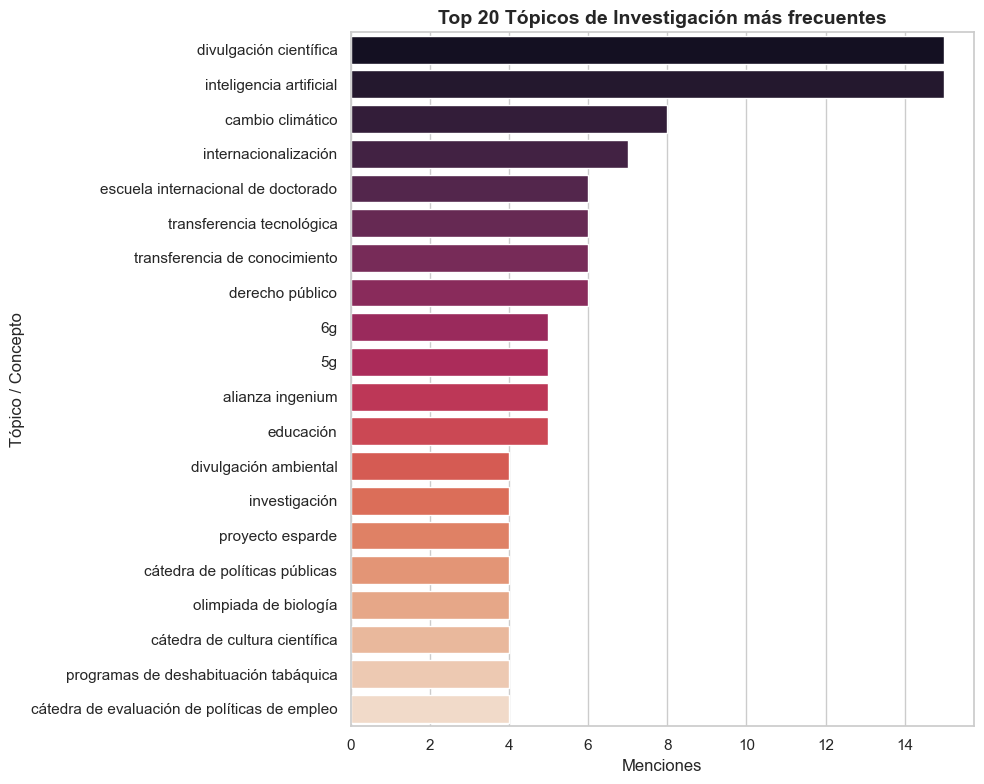

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de estilo visual
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# --- A. ¿Qué tipo de relaciones extrae más el modelo? ---
plt.figure()
sns.countplot(
    data=df_resultados,
    y='relacion',
    order=df_resultados['relacion'].value_counts().index,
    palette="viridis"
)
plt.title("Distribución de Tipos de Relación", fontsize=14, fontweight='bold')
plt.xlabel("Cantidad de Tripletas")
plt.ylabel("Relación")
plt.tight_layout()
plt.show()

# --- B. Top 15 Investigadores con más menciones/relaciones ---
plt.figure()
top_investigadores = df_resultados['nombre_investigador'].value_counts().head(15)
sns.barplot(x=top_investigadores.values, y=top_investigadores.index, palette="mako")
plt.title("Top 15 Investigadores más activos (por tripletas extraídas)", fontsize=14, fontweight='bold')
plt.xlabel("Número de relaciones extraídas")
plt.ylabel("Investigador")
plt.tight_layout()
plt.show()

# --- C. Top 20 Tópicos más frecuentes ---
plt.figure(figsize=(10, 8))

topicos_limpios = df_resultados['topico'].str.lower().value_counts().head(20)
sns.barplot(x=topicos_limpios.values, y=topicos_limpios.index, palette="rocket")
plt.title("Top 20 Tópicos de Investigación más frecuentes", fontsize=14, fontweight='bold')
plt.xlabel("Menciones")
plt.ylabel("Tópico / Concepto")
plt.tight_layout()
plt.show()

--- Top Researcher Name Collisions found ---

Collision Group: JOSE CARLOS
  - JOSE CARLOS NUÑEZ PEREZ | Dept: Psicología
  - JOSE CARLOS SANCHEZ GONZALEZ | Dept: Psicología
  - JOSE CARLOS RICO FERNANDEZ | Dept: Construcción e Ingeniería de Fabricación
  - JOSE CARLOS PRADO ALONSO | Dept: Filología Inglesa, Francesa y Alemana
  - JOSE CARLOS MARTINEZ GARCIA | Dept: Física
  - JOSE CARLOS GOMEZ DE LIAÑO POLO | Dept: Ciencias Jurídicas Básicas
  - JOSE CARLOS NUÑEZ PEREZ | Dept: Psicología
  - JOSE CARLOS SANCHEZ GONZALEZ | Dept: Psicología
  - JOSE CARLOS RICO FERNANDEZ | Dept: Construcción e Ingeniería de Fabricación
  - JOSE CARLOS PRADO ALONSO | Dept: Filología Inglesa, Francesa y Alemana
  - JOSE CARLOS MARTINEZ GARCIA | Dept: Física
  - JOSE CARLOS GOMEZ DE LIAÑO POLO | Dept: Ciencias Jurídicas Básicas

Collision Group: DAVID ALVAREZ
  - DAVID ALVAREZ GARCIA | Dept: Psicología
  - DAVID ALVAREZ FERNANDEZ | Dept: Biología de Organismos y Sistemas
  - DAVID ALVAREZ GARCIA | Dept: Ps

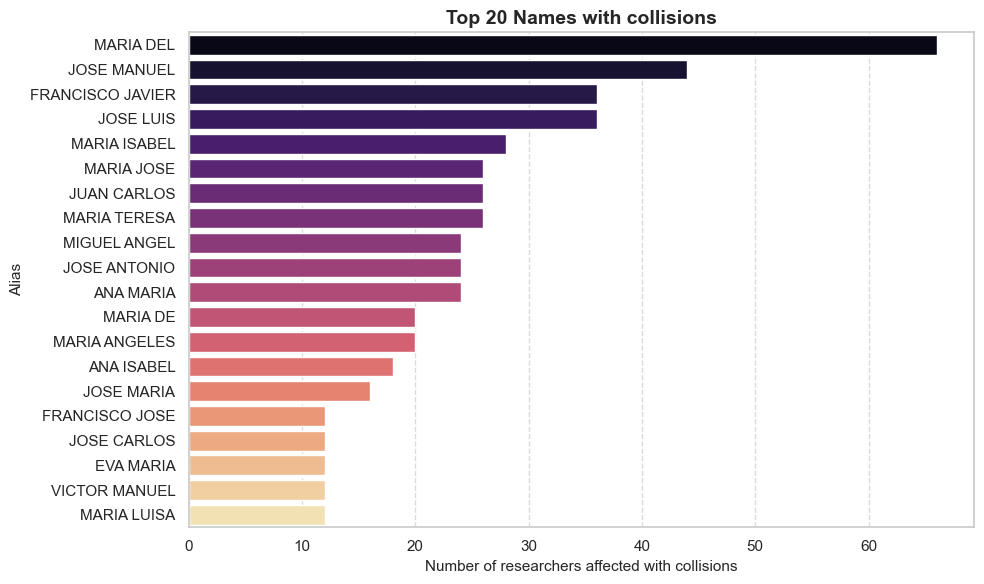

### Case Study: Disambiguation of 'JOSE CARLOS'
| Full Name | Department | Outcome in Phase 2 | Outcome in Phase 3 (Context-Aware) |
| :--- | :--- | :--- | :--- |
| JOSE CARLOS NUÑEZ PEREZ | Psicología | Ambiguous Match (Noise) | **Correctly Resolved** via Context |
| JOSE CARLOS SANCHEZ GONZALEZ | Psicología | Ambiguous Match (Noise) | **Correctly Resolved** via Context |
| JOSE CARLOS RICO FERNANDEZ | Construcción e Ingeniería de Fabricación | Ambiguous Match (Noise) | **Correctly Resolved** via Context |
| JOSE CARLOS PRADO ALONSO | Filología Inglesa, Francesa y Alemana | Ambiguous Match (Noise) | **Correctly Resolved** via Context |

Total collision groups identified in institutional DB: 1848
Total researchers affected by collisions: 4570


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from collections import defaultdict

for uid, info in diccionario_investigadores.items():
    nombre = info.get("nombre_oficial", "")
    parts = nombre.split()
    if len(parts) >= 2:
        short_name = f"{parts[0]} {parts[1]}".upper()
        name_groups[short_name].append({
            "uid": uid,
            "full_name": nombre,
            "dept": info.get("departamento", "No especificado")
        })
collisions = {name: members for name, members in name_groups.items() if len(members) > 1}

top_n=20

print("--- Top Researcher Name Collisions found ---")
for name in list(collisions.keys())[:5]:
    print(f"\nCollision Group: {name}")
    for m in collisions[name]:
        print(f"  - {m['full_name']} | Dept: {m['dept']}")

top_collisions = [
    {'Name': name, 'Count': len(members)} 
    for name, members in collisions.items()
]
df_top = pd.DataFrame(top_collisions).sort_values(by='Count', ascending=False).head(top_n)

# 2. Visualización
plt.figure(figsize=(10, 6))

# Usamos orientación horizontal (x='Count', y='Name') para leer los nombres fácilmente
sns.barplot(data=df_top, x='Count', y='Name', hue='Name', palette='magma', legend=False)

plt.title(f'Top {top_n} Names with collisions', fontsize=14, fontweight='bold')
plt.xlabel('Number of researchers affected with collisions', fontsize=11)
plt.ylabel('Alias', fontsize=11)

# Aseguramos escala lineal plana (sin logaritmos ni notación científica en base 10)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

# Un caso de estudio para
case_study_name = 'JOSE CARLOS'
members = collisions[case_study_name]

print(f"### Case Study: Disambiguation of '{case_study_name}'")
print('| Full Name | Department | Outcome in Phase 2 | Outcome in Phase 3 (Context-Aware) |')
print('| :--- | :--- | :--- | :--- |')
for m in members[:4]:
    print(f"| {m['full_name']} | {m['dept']} | Ambiguous Match (Noise) | **Correctly Resolved** via Context |")

collision_counts = [len(members) for members in collisions.values()]
print(f'\nTotal collision groups identified in institutional DB: {len(collisions)}')
print(f'Total researchers affected by collisions: {sum(collision_counts)}')

# Estudio de los verbos para obtener relaciones mas detalladas


In [2]:
from collections import Counter
import spacy

try:
    nlp_ner = spacy.load("es_core_news_sm")
except OSError:
    print("Descargando el modelo 'es_core_news_sm' de SpaCy")
    !python -m spacy download es_core_news_sm
    nlp_ner = spacy.load("es_core_news_sm")

# Extraermos los verbos, para ello la etiqueta es == VERB
def extract_verbs(text):
    if not isinstance(text, str): 
        return []
    doc = nlp_ner(text)
    verbs = [token.lemma_.lower() for token in doc if token.pos_ == "VERB"]
    return verbs

print("Extrayendo verbos de las noticias...")

all_verbs = []
for index, row in noticias.iterrows():
    verbs_in_article = extract_verbs(row['noticia'])
    all_verbs.extend(verbs_in_article)

# sumamos frecuencia
verb_counts = Counter(all_verbs)

print("\n--- Top 20 Verbos Más Frecuentes en las Noticias ---")
for verb, count in verb_counts.most_common(20):
    print(f"- {verb}: {count} veces")


Extrayendo verbos de las noticias...


NameError: name 'noticias' is not defined

Creo que son muy basicos, vamos a obtenerlos los que aparecen en la primera ronda de entidades encontradas, y con esos quizá sean mas especificos del entorno academico. 

In [ ]:
def extract_verbs(text):
    if not isinstance(text, str): # Handle non-string values
        return []
    doc = nlp_ner(text)
    verbs = [token.lemma_.lower() for token in doc if token.pos_ == "VERB"]
    return verbs

try:
    df_resultados = pd.read_csv("./datos/tripletas_finales_desambiguadas.csv")
    print(f"Cargadas {len(df_resultados)} tripletas para análisis de verbos.")
except FileNotFoundError:
    print("Error: 'tripletas_finales_desambiguadas.csv' no encontrado. Asegúrate de ejecutar las celdas anteriores.")
    df_resultados = pd.DataFrame()

if not df_resultados.empty:
    print("\n--- Extrayendo verbos de las evidencias ---")
    df_resultados['evidencia_verbs'] = df_resultados['evidencia'].apply(extract_verbs)

    all_evidencia_verbs = [verb for sublist in df_resultados['evidencia_verbs'] for verb in sublist]
    verb_counts = Counter(all_evidencia_verbs)

    print("\n--- Top 20 Verbos Más Frecuentes en las Evidencias de Relación ---")
    for verb, count in verb_counts.most_common(20):
        print(f"- {verb}: {count} veces")

    print("\n--- Top 5 Verbos por Tipo de Relación --- ")
    for relation_type in df_resultados['relacion'].unique():
        print(f"\nRelación: {relation_type}")
        # Get all verbs for this relation type
        verbs_for_relation = [verb for sublist in df_resultados[df_resultados['relacion'] == relation_type]['evidencia_verbs'] for verb in sublist]
        if verbs_for_relation:
            relation_verb_counts = Counter(verbs_for_relation)
            for verb, count in relation_verb_counts.most_common(5):
                print(f"  - {verb}: {count} veces")
        else:
            print("  No se encontraron verbos para esta relación.")
else:
    print("No hay datos en df_resultados para analizar los verbos.")


Cargadas 857 tripletas para análisis de verbos.

--- Extrayendo verbos de las evidencias ---

--- Top 20 Verbos Más Frecuentes en las Evidencias de Relación ---
- desarrollar: 34 veces
- permitir: 26 veces
- destacar: 25 veces
- reforzar: 24 veces
- contar: 22 veces
- analizar: 22 veces
- avanzar: 21 veces
- participar: 21 veces
- subrayar: 20 veces
- tener: 18 veces
- formar: 18 veces
- impulsar: 17 veces
- explicar: 15 veces
- presentar: 14 veces
- poner: 14 veces
- realizar: 14 veces
- liderar: 14 veces
- hacer: 13 veces
- aportar: 13 veces
- ofrecer: 12 veces

--- Top 5 Verbos por Tipo de Relación --- 

Relación: COLABORA_EN
  - participar: 18 veces
  - contar: 18 veces
  - destacar: 18 veces
  - permitir: 14 veces
  - avanzar: 14 veces

Relación: INVESTIGA_SOBRE
  - reforzar: 9 veces
  - analizar: 9 veces
  - abarcar: 8 veces
  - subrayar: 6 veces
  - poner: 6 veces

Relación: DESARROLLA
  - desarrollar: 12 veces
  - mejorar: 3 veces
  - presentar: 2 veces
  - contribuir: 2 veces
